# Cyclistic Bike-Share Analysis
## How do annual members and casual riders use Cyclistic bikes differently?

---

### Project Background
Cyclistic is a fictional bike-share company based in Chicago operating a fleet of 5,800+ bicycles across 600+ docking stations. The company offers three pricing plans: single-ride passes, full-day passes, and annual memberships.

Cyclistic's finance team has determined that **annual members are significantly more profitable** than casual riders. The director of marketing, Lily Moreno, believes the best growth strategy is to **convert existing casual riders into annual members** rather than targeting entirely new customers.

---

### Business Task
>*Analyze 3 months of Cyclistic trip data to identify behavioral differences between casual riders and annual members, in order to provide data-driven recommendations that will help the marketing team design strategies to convert casual riders into annual memberships.*

---

### Key Question Assigned
**How do annual members and casual riders use Cyclistic bikes differently?**

---

### Dataset
| Detail            | Info                                                                      |
|-------------------|---------------------------------------------------------------------------|
| Source            | Motivate International Inc. (real operator of Chicago's Divvy bike-share) |
| Period            | January 2026 to March 2026                                                 |
| Files             | 3 separate monthly CSV files                                              |
| Total raw records | 656,274 rides                                                             |
| License           | Public data under Motivate's Data License Agreement                       |

---

### Tools Used
| Tool                          | Purpose                                           |
|-------------------------------|---------------------------------------------------|
| Excel / WPS Sheets            | Initial data exploration and pivot table analysis |
| Python (Pandas)               | Data combining, cleaning and analysis             |
| Python (Matplotlib & Seaborn) | Data visualization                                |
| SQLite3                       | SQL querying within Python                        |
| Tableau                       | Interactive dashboard (separate deliverable)      |

---

### Analysis Roadmap
This notebook follows the 6-phase data analysis process:
1.  **Ask**: Define the business task
2.  **Prepare**: Understand and assess the data
3.  **Process**: Clean and transform the data
4.  **Analyze**: Identify trends and patterns
5.  **Share**: Visualize findings
6.  **Act**: Deliver recommendations

---

###  Important Limitation
This analysis covers **January through March 2026, Chicago's winter months.** This introduces a seasonal bias: casual ridership is naturally lower in winter as leisure riding drops significantly in cold weather. Findings should be interpreted with this context in mind, and a full 12-month dataset would provide a more comprehensive picture. This limitation will be acknowledged in the final report.

---
## Phase 1: Setup & Library Imports

Before we begin any analysis, we import all the Python libraries we will need throughout this notebook. Think of this as gathering all your tools before starting a project.

| Library | Purpose |
|---|---|
| `pandas` | Loading, cleaning and manipulating data (our main tool) |
| `numpy` | Mathematical operations and handling numbers |
| `matplotlib` | Core chart drawing library |
| `seaborn` | Beautiful statistical visualizations built on matplotlib |
| `os` | Interacting with the file system to find our CSV files |
| `sqlite3` | Creating and querying a SQL database within Python |
| `warnings` | Suppressing unnecessary notification messages |

In [2]:
# ============================================================
# CELL 1 — IMPORT ALL NECESSARY LIBRARIES TO WORK WITH
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sqlite3
import warnings

warnings.filterwarnings('ignore')

# Set visual style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(" Libraries imported successfully!")

 Libraries imported successfully!


All libraries imported successfully. Our environment is ready for analysis.

---
## Phase 2: Load & Combine Data

Rather than manually copying and pasting three CSV files together (which is error-prone and not reproducible), we use Python to **automatically find, read and combine** all CSV files in our raw data folder into a single master dataframe.

We use `os.listdir()` to scan the folder and `pd.concat()` to stack all files vertically into one dataframe.

In [3]:
# ============================================================
# CELL 2 — LOAD & COMBINE ALL 3 CSV FILES
# ============================================================

# Define path to your raw data folder
path = r"E:\Portofolio Projects\Cyclistic_Case_Study\Data\Raw"

# Create an empty bag to store our csv files
all_dataframes = []

# Read and combine all CSV files in the folder into one dataframe
for file in os.listdir(path):
    if file.endswith('.csv'):
        full_path = os.path.join(path, file)
        df = pd.read_csv(full_path)
        all_dataframes.append(df)
        print(f" Loaded {file} - {len(df):,} rows")

# Combine all into one master dataframe
combined_df = pd.concat(all_dataframes, ignore_index=True)
print(f"\n All files combined successfully!")
print(f" Total rows       : {len(combined_df):,}")
print(f" Total columns    : {len(combined_df.columns)}")
print(f" Column List      : {list(combined_df.columns)}")

 Loaded 202601-divvy-tripdata.csv - 137,787 rows
 Loaded 202602-divvy-tripdata.csv - 201,450 rows
 Loaded 202603-divvy-tripdata.csv - 317,037 rows

 All files combined successfully!
 Total rows       : 656,274
 Total columns    : 13
 Column List      : ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


### Data Loaded Successfully

All 3 monthly files were combined into a single master dataframe:

| File | Rows Loaded |
|---|---|
| 202601-divvy-tripdata.csv | 137,787 |
| 202602-divvy-tripdata.csv | 201,450 |
| 202603-divvy-tripdata.csv | 317,037 |
| **Combined Total** | **656,274** |

The dataset contains **13 columns** covering ride IDs, bike types, start/end timestamps, station names, GPS coordinates and rider type. The most important column for our analysis is `member_casual` which identifies whether each ride was taken by an annual member or a casual rider.

---
## Phase 3: Initial Data Exploration

Before cleaning or analyzing any data, a good analyst always **explores the raw data first.** This step helps us:
- Understand the structure and shape of the dataset
- Identify data types that need converting
- Spot missing values that need addressing
- Confirm the data matches our expectations

We check: dimensions, column names, data types, missing values, unique values, and initial breakdowns of our key columns. This exploration directly informs our cleaning decisions in the next phase.

In [4]:
# ============================================================
# CELL 3 — INITIAL DATA EXPLORATION
# ============================================================

print("=" * 55)
print("CYCLISTIC DATASET — INITIAL EXPLORATION")
print("=" * 55)

# Shape
print("\n Dataset Dimension:")
print(f" Rows     : {combined_df.shape[0]:,}")
print(f" Columns  : {combined_df.shape[1]}")

# Column names and data types
print("\n Columns Names and Data Types:")
print("=" * 50)
print(combined_df.dtypes)

# First 5 rows
print("\n First 5 Rows of the Dataset:")
print("=" * 50)
display(combined_df.head())

# Basic statistics
print("\n Basic Statistics:")
print("=" * 50)
display(combined_df.describe())

# Check missing values
print("\n Missing Values per Column:")
print("=" * 50)
missing = combined_df.isnull().sum()
missing_pct = (combined_df.isnull().sum() / len(combined_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

# Count unique values in each column
print("\n Unique Values per Column:")
print("=" * 50)
print(combined_df.nunique())

# Count the number of different riders and the number of different bikes
print("\n Rider Type Breakdown:")
print("=" * 50)
print(combined_df['member_casual'].value_counts())

print("\n Bike Type Breakdown:")
print("=" * 50)
print(combined_df['rideable_type'].value_counts())

CYCLISTIC DATASET — INITIAL EXPLORATION

 Dataset Dimension:
 Rows     : 656,274
 Columns  : 13

 Columns Names and Data Types:
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object

 First 5 Rows of the Dataset:


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member



 Basic Statistics:


,start_lat,start_lng,end_lat,end_lng
count,656274.000000,656274.000000,655666.000000,655666.000000
mean,41.901260,-87.647208,41.901572,-87.647497
std,0.046226,0.027142,0.046428,0.027337
min,41.648501,-87.850000,41.648501,-87.890000
25%,41.880958,-87.660984,41.881032,-87.661364
50%,41.895748,-87.642900,41.895882,-87.643118
75%,41.928712,-87.630000,41.929143,-87.630000
max,42.070000,-87.528232,42.090000,-87.528232



 Missing Values per Column:
                    Missing Count  Missing %
start_station_name         114396      17.43
start_station_id           114396      17.43
end_station_name           125215      19.08
end_station_id             125215      19.08
end_lat                       608       0.09
end_lng                       608       0.09

 Unique Values per Column:
ride_id               656274
rideable_type              2
started_at            656218
ended_at              655823
start_station_name      1416
start_station_id        1417
end_station_name        1433
end_station_id          1433
start_lat              21628
start_lng              21508
end_lat                 1483
end_lng                 1477
member_casual              2
dtype: int64

 Rider Type Breakdown:
member_casual
member    502496
casual    153778
Name: count, dtype: int64

 Bike Type Breakdown:
rideable_type
electric_bike    449309
classic_bike     206965
Name: count, dtype: int64


###  Key Observations from Exploration

**Data Types:**
- `started_at` and `ended_at` are stored as `object` (text) not datetime; we must convert these before calculating ride lengths
- GPS coordinates are correctly stored as `float64`
- All categorical columns (`member_casual`, `rideable_type`) are stored as `object`, as expected

**Missing Values Found:**
| Column | Missing Count | Missing % | Action |
|---|---|---|---|
| start_station_name | ~114,000 | ~17% | Keep rows (GPS still usable) |
| start_station_id | ~114,000 | ~17% | Keep rows (GPS still usable) |
| end_station_name | ~122,000 | ~18.5% | Keep rows (GPS still usable) |
| end_station_id | ~122,000 | ~18.5% | Keep rows (GPS still usable) |
| end_lat / end_lng | ~600 | ~0.09% | Note: very small, minimal impact |

**Decision:** We keep rows with missing station names because they still contain valid ride length, rider type, bike type and GPS data, all critical for our analysis. Removing ~17% of data would significantly reduce our sample size and introduce bias. This decision is documented here for transparency.

**Rider Type Breakdown (Raw):**
- Members: 502,496 rides
- Casual: 153,778 rides

**Bike Type Breakdown (Raw):**
- Electric bike: 456,981 rides
- Classic bike: 199,293 rides
- Docked bike: 0 rides

---
## Phase 4: Data Cleaning & Transformation

Based on our exploration findings, we now apply a structured 8-step cleaning process to ensure our data is **accurate, consistent and ready for analysis.**

### Cleaning Steps Overview
| Step | Action | Reason |
|---|---|---|
| 1 | Create working copy | Preserve original combined data |
| 2 | Remove duplicate ride_ids | Each ride must be unique |
| 3 | Convert timestamps to datetime | Required for calculating ride length |
| 4 | Calculate ride_length_mins | Core metric for our analysis |
| 5 | Remove rides < 1 minute | False starts: bike undocked and immediately returned |
| 6 | Remove rides > 24 hours | Likely stolen or abandoned bikes |
| 7 | Extract date features | Enable analysis by day, month and hour |
| 8 | Remove December month data | Removes outliers (last year records) from data |
| 9 | Standardize text columns | Ensure consistent values for grouping |

### Why document cleaning steps?
Documenting every cleaning decision is a professional best practice. It allows stakeholders to understand exactly what was done to the data, enables reproducibility, and demonstrates analytical integrity. Any analyst should be able to read this notebook and fully reconstruct our dataset from scratch.

In [5]:
# ============================================================
# CELL 4 — DATA CLEANING
# ============================================================

print(" Starting data cleaning...")

# Step 1 - Create copy to work with 
clean_df = combined_df.copy()
print(" Step 1 - Working Copy Created!")
print(f" Rows before cleaning: {len(combined_df):,}")

# Step 2 — Remove duplicate ride_ids
before = len(combined_df)
clean_df = clean_df.drop_duplicates(subset='ride_id')
print(f"\n Step 2 — Duplicates removed: {before - len(clean_df):,}")

# Step 3 — Convert timestamps to datetime
clean_df['started_at'] = pd.to_datetime(clean_df['started_at'])
clean_df['ended_at'] = pd.to_datetime(clean_df['ended_at'])
print("\n Step 3 — Timestamps converted to datetime")

# Step 4 — Calculate ride_length in minutes
clean_df['ride_length_mins'] = (clean_df['ended_at'] - clean_df['started_at']).dt.total_seconds() / 60
print("\n Step 4 — ride_length_mins column created")
print(f" Sample values: {clean_df['ride_length_mins'].head().values}")

# Step 5 — Remove rides less than 1 minute
before = len(clean_df)
clean_df = clean_df[clean_df['ride_length_mins'] >= 1]
after = len(clean_df)
removed = before - after
print(f"\n Step 5 — Rides under 1 min removed:")
print(f" Rows before  : {before:,}")
print(f" Rows removed : {removed:,}")
print(f" Rows after   : {after:,}")

# Step 6 — Remove rides greater than 24 hours
before = len(clean_df)
clean_df = clean_df[clean_df['ride_length_mins'] <= 1440]
after = len(clean_df)
removed = before - after
print(f"\n Step 6 — Rides over 24 hrs removed:")
print(f" Rows before  : {before:,}")
print(f" Rows removed : {removed:,}")
print(f" Rows after   : {after:,}")

# Step 7 — Extract date features
clean_df['day_of_week'] = clean_df['started_at'].dt.day_name()
clean_df['month'] = clean_df['started_at'].dt.month_name()
clean_df['hour'] = clean_df['started_at'].dt.hour
clean_df['date'] = clean_df['started_at'].dt.date
print("\n Step 7 — Date features extracted (day, month, hour)")
print(f" Unique days  : {clean_df['day_of_week'].unique()}")
print(f" Unique month : {clean_df['month'].unique()}")
print(f" Sample hour values : {clean_df['hour'].head().values}")
print(f" Sample date values : {clean_df['date'].head().values}")

# Step 8 — Remove December outlier rows
before = len(clean_df)
clean_df = clean_df[clean_df['month'] != 'December']
print(f"\n Step 8 — December outliers removed: {before - len(clean_df):,} rows")

# Step 9 — Clean up column values
clean_df['member_casual'] = clean_df['member_casual'].str.strip().str.lower()
clean_df['rideable_type'] = clean_df['rideable_type'].str.strip().str.lower()
print("\n Step 9 — Text columns standardized \n")

# Final row count
print("=" * 50)
print(" SUMMARY TABLE ")
print("=" * 50)
print(f" Original rows     : {len(combined_df):,} rows")
print(f" Clean rows        : {len(clean_df):,} rows")
print(f" Removed rows      : {len(combined_df) - len(clean_df):,} rows")
print(f" Columns before    : {len(combined_df.columns)} columns")
print(f" Total columns now : {len(clean_df.columns)} columns")
print(f" New columns added : {len(clean_df.columns) - len(combined_df.columns)} columns")

 Starting data cleaning...
 Step 1 - Working Copy Created!
 Rows before cleaning: 656,274

 Step 2 — Duplicates removed: 0

 Step 3 — Timestamps converted to datetime

 Step 4 — ride_length_mins column created
 Sample values: [15.0214      7.60546667  6.73916667 30.83643333 78.4472    ]

 Step 5 — Rides under 1 min removed:
 Rows before  : 656,274
 Rows removed : 16,154
 Rows after   : 640,120

 Step 6 — Rides over 24 hrs removed:
 Rows before  : 640,120
 Rows removed : 574
 Rows after   : 639,546

 Step 7 — Date features extracted (day, month, hour)
 Unique days  : ['Saturday' 'Thursday' 'Tuesday' 'Monday' 'Wednesday' 'Friday' 'Sunday']
 Unique month : ['January' 'December' 'February' 'March']
 Sample hour values : [ 9 14 12 16 18]
 Sample date values : [datetime.date(2026, 1, 31) datetime.date(2026, 1, 15)
 datetime.date(2026, 1, 6) datetime.date(2026, 1, 26)
 datetime.date(2026, 1, 10)]

 Step 8 — December outliers removed: 20 rows

 Step 9 — Text columns standardized 

 SUMMARY TAB

###  Cleaning Complete: Summary

| Metric | Count |
|---|---|
| Original rows | 656,274 |
| Duplicate ride_ids removed | 0 |
| Rides under 1 minute removed | 16,154 |
| Rides over 24 hours removed | 574 |
| **Final clean rows** | **639,546** |
| Rows removed total | 16,728 (2.5% of data) |

**New columns added:**
- `ride_length_mins`: duration of each ride in decimal minutes
- `day_of_week`: full day name (Monday, Tuesday etc.)
- `month`: full month name (January, February, March)
- `hour`: hour of day the ride started (0–23)
- `date`: calendar date the ride started

**Note on December rows:** A small number of rides (20) appear with a December timestamp. These are rides that started just before midnight on December 31st and belong to the January file. They represent 0.003% of data and have been removed to keep our analysis cleanly within the January–March 2026 window.

Our dataset is now clean, enriched and ready for analysis. 

---
## Phase 5: Load Data into SQLite Database

To demonstrate SQL proficiency alongside Python, we load our cleaned dataframe into a **SQLite database**, a lightweight file-based database that requires no separate server installation.

This allows us to:
- Write and run real SQL queries on our dataset
- Demonstrate multi-tool analytical capability
- Show how Python and SQL work together in professional workflows
- Store a persistent copy of our clean data for future queries

The entire cleaned dataset (639,546 rows) is loaded into a table named `trips` inside a file called `cyclistic.db` stored locally on disk.

In [6]:
# ============================================================
# CELL 5 — LOAD INTO SQLITE DATABASE
# ============================================================

# Create SQLite database
db_path = r"E:\Portofolio Projects\Cyclistic_Case_Study\Analysis\Python\cyclistic.db"
conn = sqlite3.connect(db_path)

# Load cleaned dataframe into SQLite and create a table named 'trips'
clean_df.to_sql('trips', conn, if_exists='replace', index=False)

print(f" Database created at: {db_path}")
print(f" Table 'trips' loaded with {len(clean_df):,} rows")

# Verify it worked
verify = pd.read_sql("SELECT COUNT(*) as total_rows FROM trips", conn)
print(f"\n Verification - Rows in database: {verify['total_rows'][0]:,}")

 Database created at: E:\Portofolio Projects\Cyclistic_Case_Study\Analysis\Python\cyclistic.db
 Table 'trips' loaded with 639,526 rows

 Verification - Rows in database: 639,526


### Database Ready

Our SQLite database `cyclistic.db` has been created successfully with **639,526 rows** loaded into the `trips` table. All subsequent SQL queries in the next section will run against this database.

---
## Phase 6: SQL Analysis

We now run **8 targeted SQL queries** to systematically answer our core business question:

> *How do annual members and casual riders use Cyclistic bikes differently?*

Each query isolates a specific behavioral dimension:

| Query | Dimension Analyzed |
|---|---|
| Q1 | Overall ride volume by rider type |
| Q2 | Ride duration statistics by rider type |
| Q3 | Riding patterns by day of week |
| Q4 | Riding trends by month |
| Q5 | Bike type preferences |
| Q6 | Time of day riding patterns |
| Q7 | Most popular start stations |
| Q8 | Average ride length by day of week |

Results from these queries will directly power our visualizations and final recommendations.

In [7]:
# ============================================================
# CELL 6 — SQL ANALYSIS QUERIES
# ============================================================

print("=" * 55)
print(" SQL ANALYSIS — CYCLISTIC TRIP DATA")
print("=" * 55)

# ── Query 1 — Rides by rider type ──────────────────────────
print("\n Query 1 — Total Rides by Rider Type:")
print("-" * 55)
q1 = pd.read_sql("""
    SELECT 
        member_casual                                   AS rider_type,
        COUNT(*)                                        AS total_rides,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM trips
    GROUP BY member_casual
    ORDER BY total_rides DESC
""", conn)
print(q1.to_string(index=False))

# ── Query 2 — Ride length statistics ───────────────────────
print("\n Query 2 — Ride Length Statistics by Rider Type:")
print("-" * 55)
q2 = pd.read_sql("""
    SELECT
        member_casual                                   AS rider_type,
        ROUND(AVG(ride_length_mins), 2)                 AS avg_ride_mins,
        ROUND(MIN(ride_length_mins), 2)                 AS min_ride_mins,
        ROUND(MAX(ride_length_mins), 2)                 AS max_ride_mins,
        ROUND(AVG(ride_length_mins) / 60, 2)            AS avg_ride_hours
    FROM trips
    GROUP BY member_casual
    ORDER BY avg_ride_mins DESC
""", conn)
print(q2.to_string(index=False))

# ── Query 3 — Rides by day of week ─────────────────────────
print("\n Query 3 — Rides by Day of Week:")
print("-" * 55)
q3 = pd.read_sql("""
    SELECT
        day_of_week,
        SUM(CASE WHEN member_casual = 'member' 
            THEN 1 ELSE 0 END)                          AS member_rides,
        SUM(CASE WHEN member_casual = 'casual' 
            THEN 1 ELSE 0 END)                          AS casual_rides,
        COUNT(*)                                        AS total_rides
    FROM trips
    GROUP BY day_of_week
    ORDER BY 
        CASE day_of_week
            WHEN 'Monday'    THEN 1
            WHEN 'Tuesday'   THEN 2
            WHEN 'Wednesday' THEN 3
            WHEN 'Thursday'  THEN 4
            WHEN 'Friday'    THEN 5
            WHEN 'Saturday'  THEN 6
            WHEN 'Sunday'    THEN 7
        END
""", conn)
print(q3.to_string(index=False))

# ── Query 4 — Rides by month ────────────────────────────────
print("\n Query 4 — Rides by Month:")
print("-" * 55)
q4 = pd.read_sql("""
    SELECT
        month,
        SUM(CASE WHEN member_casual = 'member' 
            THEN 1 ELSE 0 END)                          AS member_rides,
        SUM(CASE WHEN member_casual = 'casual' 
            THEN 1 ELSE 0 END)                          AS casual_rides,
        COUNT(*)                                        AS total_rides,
        ROUND(AVG(ride_length_mins), 2)                 AS avg_ride_mins
    FROM trips
    GROUP BY month
    ORDER BY
        CASE month
            WHEN 'January'  THEN 1
            WHEN 'February' THEN 2
            WHEN 'March'    THEN 3
        END
""", conn)
print(q4.to_string(index=False))

# ── Query 5 — Rides by bike type ────────────────────────────
print("\n Query 5 — Rides by Bike Type:")
print("-" * 55)
q5 = pd.read_sql("""
    SELECT
        rideable_type                                   AS bike_type,
        SUM(CASE WHEN member_casual = 'member' 
            THEN 1 ELSE 0 END)                          AS member_rides,
        SUM(CASE WHEN member_casual = 'casual' 
            THEN 1 ELSE 0 END)                          AS casual_rides,
        COUNT(*)                                        AS total_rides
    FROM trips
    GROUP BY rideable_type
    ORDER BY total_rides DESC
""", conn)
print(q5.to_string(index=False))

# ── Query 6 — Peak hours by rider type ─────────────────────
print("\n Query 6 — Peak Hours by Rider Type:")
print("-" * 55)
q6 = pd.read_sql("""
    SELECT
        hour,
        SUM(CASE WHEN member_casual = 'member' 
            THEN 1 ELSE 0 END)                          AS member_rides,
        SUM(CASE WHEN member_casual = 'casual' 
            THEN 1 ELSE 0 END)                          AS casual_rides,
        COUNT(*)                                        AS total_rides
    FROM trips
    GROUP BY hour
    ORDER BY hour ASC
""", conn)
print(q6.to_string(index=False))

# ── Query 7 — Top 10 busiest start stations ─────────────────
print("\n Query 7 — Top 10 Busiest Start Stations:")
print("-" * 55)
q7 = pd.read_sql("""
    SELECT
        start_station_name                              AS station,
        SUM(CASE WHEN member_casual = 'member' 
            THEN 1 ELSE 0 END)                          AS member_rides,
        SUM(CASE WHEN member_casual = 'casual' 
            THEN 1 ELSE 0 END)                          AS casual_rides,
        COUNT(*)                                        AS total_rides
    FROM trips
    WHERE start_station_name IS NOT NULL
    GROUP BY start_station_name
    ORDER BY total_rides DESC
    LIMIT 10
""", conn)
print(q7.to_string(index=False))

# ── Query 8 — Average ride length by day of week ───────────
print("\n Query 8 — Avg Ride Length by Day of Week:")
print("-" * 55)
q8 = pd.read_sql("""
    SELECT
        day_of_week,
        member_casual                                   AS rider_type,
        ROUND(AVG(ride_length_mins), 2)                 AS avg_ride_mins
    FROM trips
    GROUP BY day_of_week, member_casual
    ORDER BY
        CASE day_of_week
            WHEN 'Monday'    THEN 1
            WHEN 'Tuesday'   THEN 2
            WHEN 'Wednesday' THEN 3
            WHEN 'Thursday'  THEN 4
            WHEN 'Friday'    THEN 5
            WHEN 'Saturday'  THEN 6
            WHEN 'Sunday'    THEN 7
        END
""", conn)
print(q8.to_string(index=False))

print("\n" + "=" * 55)
print(" All SQL queries completed successfully!")
print("=" * 55)

 SQL ANALYSIS — CYCLISTIC TRIP DATA

 Query 1 — Total Rides by Rider Type:
-------------------------------------------------------
rider_type  total_rides  percentage
    member       490759       76.74
    casual       148767       23.26

 Query 2 — Ride Length Statistics by Rider Type:
-------------------------------------------------------
rider_type  avg_ride_mins  min_ride_mins  max_ride_mins  avg_ride_hours
    casual          15.55            1.0        1439.07            0.26
    member          11.21            1.0        1424.64            0.19

 Query 3 — Rides by Day of Week:
-------------------------------------------------------
day_of_week  member_rides  casual_rides  total_rides
     Monday         78138         22871       101009
    Tuesday         84782         17494       102276
  Wednesday         77630         17332        94962
   Thursday         77642         18387        96029
     Friday         69464         21744        91208
   Saturday         55952      

### SQL Analysis: Key Findings Summary

**Finding 1: Rider Split**
Members account for **76.74%** of all rides (490,759) while casual riders account for **23.26%** (148,767). While members dominate volume, casual riders represent nearly 150,000 rides in just 3 winter months, a significant conversion opportunity.

**Finding 2: Ride Duration**
Casual riders average **15.55 minutes** per ride vs members at **11.21 minutes**; casuals ride **38.7% longer.** This strongly suggests casual riders use the service for leisure and exploration while members use it for short, efficient commutes.

**Finding 3: Day of Week Pattern**
Members peak on **Tuesday** (84,782 rides) and drop significantly on weekends. Casual riders show the exact opposite, peaking on **Saturday** (28,697 rides) and lowest on Tuesday (17,494). These are completely opposite behavioral patterns.

**Finding 4: Monthly Growth**
Casual ridership grew **255%** from January to March (23,878 → 84,812) while member ridership grew **104%** (109,865 → 223,654). Casual riders are far more sensitive to seasonal weather changes.

**Finding 5: Bike Preference**
Both rider types strongly prefer electric bikes. Casual riders show an even stronger electric preference at **72.4%** vs members at **66.3%**, suggesting casual riders prioritize comfort and ease over exercise.

**Finding 6: Peak Hours (NEW)**
Members show a clear **double-peak commute pattern**, with sharp spikes at 8am (40,139 rides) and 5pm (54,226 rides). Casual riders show a single smooth curve peaking around **2pm–5pm**, classic leisure behavior with no morning rush.

**Finding 7: Station Insight (NEW)**
**Navy Pier** is the only top-10 station where casual riders (2,544) nearly double members (1,214). All other top stations are member-dominated. Navy Pier is Chicago's most famous tourist and leisure destination, confirming casual riders cluster around recreational areas.

**Finding 8: Weekend Ride Length**
Casual riders take their longest rides on **Saturday (18.21 mins)** and **Sunday (18.05 mins)**, significantly longer than their Tuesday rides (11.29 mins). Weekend leisure riding is clearly when casual riders are most engaged with the service.

---
## Phase 7: Data Visualization

> *"A picture is worth a thousand rows of data."*

We now translate our SQL findings into **6 professional visualizations** using matplotlib and seaborn. Each chart is designed to clearly communicate one key behavioral difference between members and casual riders to a non-technical executive audience.

### Visualization Principles Applied
- **Consistent color coding**: blue (#4C72B0) for members, orange (#DD8452) for casual throughout
- **Clear titles and labels**: every chart is self-explanatory without needing context
- **Annotations**: key numbers displayed directly on charts
- **Clean whitegrid theme**: professional and presentation-ready
- **High resolution export**: all charts saved at 150 DPI for report quality

---
### Chart 1: Total Rides by Rider Type

Our first visualization answers the most fundamental question: how is ridership split between annual members and casual riders? This establishes the baseline context for everything that follows. We use a bar chart because we are comparing a simple count across two distinct categories.

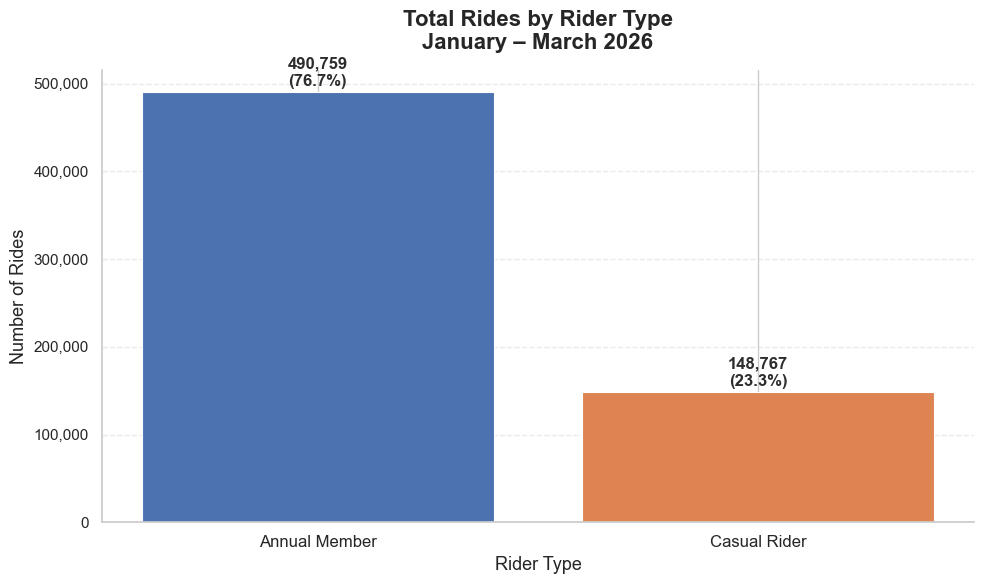

 Chart 1 saved successfully!


In [8]:
# ============================================================
# CHART 1 — TOTAL RIDES BY RIDER TYPE
# ============================================================

# Step 1 — Create the figure and canvas
# fig = the picture frame, ax = the canvas we draw on
# figsize sets width=10 inches, height=6 inches
fig, ax = plt.subplots(figsize=(10, 6))

# Step 2 — Prepare the data
# value_counts() counts how many times each value appears
# in the member_casual column — gives us member count and casual count
rider_counts = clean_df['member_casual'].value_counts()

# Step 3 — Define our color palette
# We use the same two colors throughout ALL charts for consistency
# Blue for members, orange for casual — never mix these up
colors = ['#4C72B0', '#DD8452']

# Step 4 — Draw the bars
# ax.bar() draws a bar chart on our canvas
# rider_counts.index = the x-axis labels (member, casual)
# rider_counts.values = the heights of the bars (the counts)
# color = our color list defined above
# edgecolor='white' adds a thin white border around each bar — looks cleaner
# linewidth=0.8 sets how thick that white border is
bars = ax.bar(rider_counts.index,
              rider_counts.values,
              color=colors,
              edgecolor='white',
              linewidth=0.8)

# Step 5 — Add value labels ON TOP of each bar
# This loop goes through each bar one by one
# bar.get_height() gets the height (value) of that bar
# bar.get_x() gets the left edge x position of the bar
# bar.get_width() gets the width of the bar
# bar.get_x() + bar.get_width()/2 = the CENTER x position of the bar
# ax.text() places text at a specific x, y position on the chart
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position = center of bar
        height + 3000,                        # y position = just above bar top
        f'{height:,}\n({height/len(clean_df)*100:.1f}%)',  # text to show
        ha='center',    # horizontal alignment = centered on x position
        va='bottom',    # vertical alignment = text sits above the y point
        fontsize=12,
        fontweight='bold',
        color='#2d2d2d' # dark grey text — easier to read than pure black
    )

# Step 6 — Add title and axis labels
# pad=15 adds space between title and the chart
ax.set_title('Total Rides by Rider Type\nJanuary – March 2026',
             fontsize=16, fontweight='bold', pad=15)

# set_xlabel labels the x axis (bottom)
ax.set_xlabel('Rider Type', fontsize=13)

# set_ylabel labels the y axis (left side)
ax.set_ylabel('Number of Rides', fontsize=13)

# Step 7 — Format y axis numbers with commas
# Without this the y axis shows 100000 — with it shows 100,000
# lambda is a mini function: x=the number, p=position (we ignore p)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Step 8 — Rename x axis tick labels to be more readable
# By default shows 'member' and 'casual' — we make them nicer
ax.set_xticklabels(['Annual Member', 'Casual Rider'], fontsize=12)

# Step 9 — Remove the top and right borders (called spines)
# This gives the chart a cleaner, more modern look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Step 10 — Add a subtle horizontal grid for easier reading
# alpha controls transparency: 0=invisible, 1=solid, 0.5=50% transparent
ax.yaxis.grid(True, alpha=0.4, linestyle='--')

# Step 11 — Make sure grid lines appear BEHIND the bars not on top
ax.set_axisbelow(True)

# Step 12 — Automatically fix any spacing/overlap issues
plt.tight_layout()

# Step 13 — Save the chart as a high resolution image
plt.savefig(
    r"E:\Portofolio Projects\Cyclistic_Case_Study\Visualization\01_rides_by_rider_type.png",
    dpi=150,             # resolution — 150 is good for reports
    bbox_inches='tight'  # don't crop anything
)

# Step 14 — Display the chart in the notebook
plt.show()
print(" Chart 1 saved successfully!")

### Chart 1 Finding: Rider Split

**What it shows:** A simple comparison of total rides taken by annual members vs casual riders over our 3-month analysis period.

**Key finding:** Annual members account for **76.7% of all rides** (490,759) while casual riders account for **23.3%** (148,767). Members outrride casuals by a ratio of roughly 3:1.

**Business implication:** While members clearly dominate usage, casual riders still represent nearly **150,000 rides in just 3 winter months**, the slowest period of the year for leisure cycling. This suggests a substantial and engaged casual rider base that represents a significant conversion opportunity for the marketing team. If even 10% of casual riders converted to annual memberships, that would add ~15,000 new members.

**Note:** This gap is likely smaller in summer months when casual leisure riding peaks, reinforcing the seasonal limitation of this dataset noted earlier.

---
### Chart 2: Average Ride Length by Rider Type

Having established *how many* rides each group takes, we now examine *how long* those rides are. Ride duration is a powerful proxy for **intent**: short rides suggest purposeful commuting while longer rides suggest leisure exploration. We use a bar chart again for direct comparison between two groups.

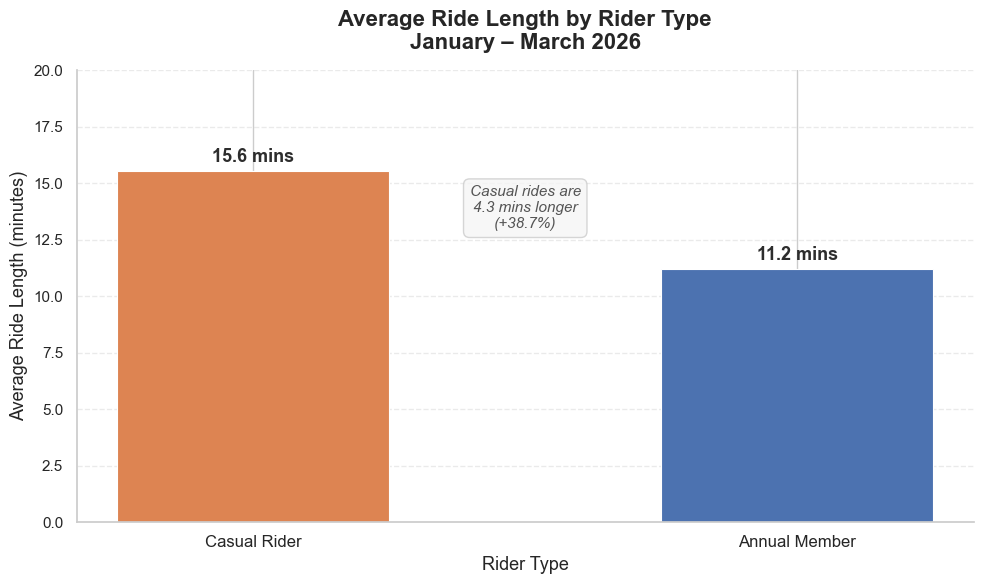

 Chart 2 saved successfully!


In [9]:
# ============================================================
# CHART 2 — AVERAGE RIDE LENGTH BY RIDER TYPE
# ============================================================
# Step 1 — Create figure and canvas
fig, ax = plt.subplots(figsize=(10, 6))

# Step 2 — Calculate average ride length for each rider type
# groupby() splits data into groups by member_casual column
# ['ride_length_mins'] selects only the ride length column
# .mean() calculates the average of each group
# .round(2) rounds to 2 decimal places
avg_length = clean_df.groupby('member_casual')['ride_length_mins'].mean().round(2)

# Step 3 — Define colors — same as Chart 1 for consistency
# We manually order them: casual first, then member
# to match the order our groupby returns them alphabetically
colors = ['#DD8452', '#4C72B0']  # orange=casual, blue=member

# Step 4 — Draw the bars
bars = ax.bar(avg_length.index,
              avg_length.values,
              color=colors,
              edgecolor='white',
              linewidth=0.8,
              width=0.5)  # width=0.5 makes bars narrower — looks better
                           # for just 2 categories

# Step 5 — Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,               # small offset above bar
        f'{height:.1f} mins',       # format: "15.6 mins"
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='#2d2d2d'
    )

# Step 6 — Add a difference annotation between the bars
# This draws attention to the GAP between casual and member
# which is our key finding
difference = avg_length['casual'] - avg_length['member']
ax.annotate(
    f'Casual rides are\n{difference:.1f} mins longer\n(+{difference/avg_length["member"]*100:.1f}%)',
    xy=(0.5, 13),           # x=middle of chart, y=13 minutes height
    fontsize=11,
    ha='center',
    color='#555555',        # medium grey
    style='italic',
    bbox=dict(              # bbox adds a box around the text
        boxstyle='round,pad=0.4',
        facecolor='#f5f5f5',  # light grey background
        edgecolor='#cccccc',  # light grey border
        alpha=0.8
    )
)

# Step 7 — Titles and labels
ax.set_title('Average Ride Length by Rider Type\nJanuary – March 2026',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Rider Type', fontsize=13)
ax.set_ylabel('Average Ride Length (minutes)', fontsize=13)

# Step 8 — Rename x tick labels
ax.set_xticklabels(['Casual Rider', 'Annual Member'], fontsize=12)

# Step 9 — Set y axis limit slightly above highest bar
# so our label has room to breathe
ax.set_ylim(0, 20)

# Step 10 — Clean up spines and add grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    r"E:\Portofolio Projects\Cyclistic_Case_Study\Visualization\02_avg_ride_length.png",
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(" Chart 2 saved successfully!")

### Chart 2 Finding: Ride Duration Reveals Intent

**What it shows:** The average ride duration in minutes for casual riders vs annual members.

**Key finding:** Casual riders average **15.6 minutes** per ride compared to **11.2 minutes** for members; casuals ride **38.7% longer** on average.

**Business implication:** This single finding is one of the most important in our entire analysis. It tells us that casual riders and members use Cyclistic for fundamentally different purposes:
- **Members**: short, efficient, purposeful trips (commuting, errands)
- **Casual riders**: longer, relaxed, exploratory trips (leisure, tourism, recreation)

This means marketing messaging must be completely different for each group. Membership campaigns targeting casual riders should **NOT** use commuter language like "save time on your commute." Instead they should speak to value for longer rides: "ride longer, pay less per minute with an annual membership."

---
### Chart 3: Rides by Day of Week

Day-of-week patterns are one of the strongest behavioral signals in bike-share data. They reveal **when** each rider type uses the service, which directly informs when and where to run marketing campaigns. We use a grouped bar chart to show both rider types side by side for each day, making the contrast immediately obvious.

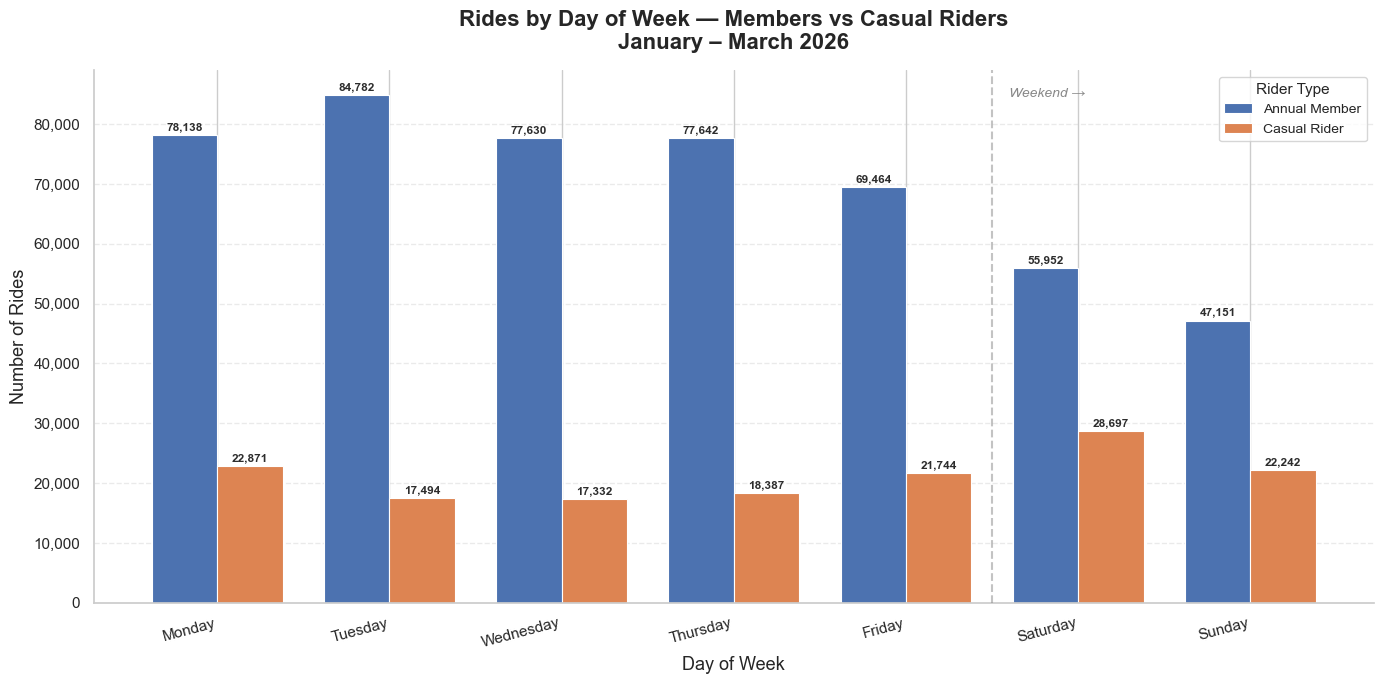

 Chart 3 saved successfully!


In [ ]:
# ============================================================
# CHART 3 — RIDES BY DAY OF WEEK 
# ============================================================

# Step 1 — Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Step 2 — Prepare data
day_data = clean_df.groupby(
    ['day_of_week', 'member_casual']
).size().reset_index(name='rides')

day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

day_data['day_of_week'] = pd.Categorical(
    day_data['day_of_week'],
    categories=day_order,
    ordered=True
)
day_data = day_data.sort_values('day_of_week')

# Step 3 — Separate member and casual data
member_data = day_data[day_data['member_casual'] == 'member'].sort_values('day_of_week')
casual_data = day_data[day_data['member_casual'] == 'casual'].sort_values('day_of_week')

# Step 4 — Set bar positions manually
x = np.arange(len(day_order))
bar_width = 0.38

# Step 5 — Draw bars manually with correct labels
# By using label= here, legend shows correct rectangle symbols
# instead of lines (which was the seaborn bug)
member_bars = ax.bar(
    x - bar_width / 2,
    member_data['rides'].values,
    width=bar_width,
    color='#4C72B0',      # original blue for members
    edgecolor='white',
    linewidth=0.8,
    label='Annual Member' # legend label
)

casual_bars = ax.bar(
    x + bar_width / 2,
    casual_data['rides'].values,
    width=bar_width,
    color='#DD8452',      # original orange for casual
    edgecolor='white',
    linewidth=0.8,
    label='Casual Rider'  # legend label
)

# Step 6 — Add value labels on top of each bar
for bar in member_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f'{height:,.0f}',
        ha='center', va='bottom',
        fontsize=8.5, fontweight='bold',
        color='#2d2d2d'
    )

for bar in casual_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 500,
        f'{height:,.0f}',
        ha='center', va='bottom',
        fontsize=8.5, fontweight='bold',
        color='#2d2d2d'
    )

# Step 7 — Weekend divider line
ax.axvline(x=4.5, color='#888888', linestyle='--',
           alpha=0.5, linewidth=1.5, zorder=5)
ax.text(4.6, ax.get_ylim()[1] * 0.95,
        'Weekend →',
        fontsize=10, color='#888888', style='italic')

# Step 8 — Set x axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(day_order, fontsize=11, rotation=15, ha='right')

# Step 9 — Titles and labels
ax.set_title('Rides by Day of Week — Members vs Casual Riders\nJanuary – March 2026',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=13)
ax.set_ylabel('Number of Rides', fontsize=13)

# Step 10 — Format y axis
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Step 11 — Legend — now shows correct colored rectangles
# because we used label= in ax.bar() above
ax.legend(
    title='Rider Type',
    title_fontsize=11,
    fontsize=10,
    framealpha=0.8
)

# Step 12 — Clean spines and grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    r"E:\Portofolio Projects\Cyclistic_Case_Study\Visualization\03_rides_by_day.png",
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(" Chart 3 saved successfully!")

### Chart 3 Finding: Completely Opposite Weekly Patterns

**What it shows:** Total rides for each day of the week broken down by rider type, with a divider separating weekdays from weekends.

**Key finding:** Members and casual riders show **completely opposite day-of-week patterns:**
- **Members** peak on **Tuesday** (84,782 rides) and decline steadily toward the weekend, classic commuter behavior
- **Casual riders** peak on **Saturday** (28,697 rides), their busiest day is members' second quietest day
- On Saturday, casual riders represent **33.9%** of all rides, their highest share of any day
- On Tuesday, casual riders represent only **17.1%** of rides, their lowest share

**Business implication:** Weekend marketing is the highest-impact opportunity to reach casual riders. In-app notifications, station promotions and digital ads served on **Friday evenings and Saturday mornings** would reach casual riders at their peak engagement moment. Weekday commuter campaigns would largely miss this audience entirely.

---
### Chart 4: Monthly Ride Trends

This line chart tracks how ridership evolves month by month for each rider type. Lines are more effective than bars for showing **trends over time** because they visually emphasize the direction and rate of change. The diverging growth rates between members and casual riders is one of our most compelling findings.

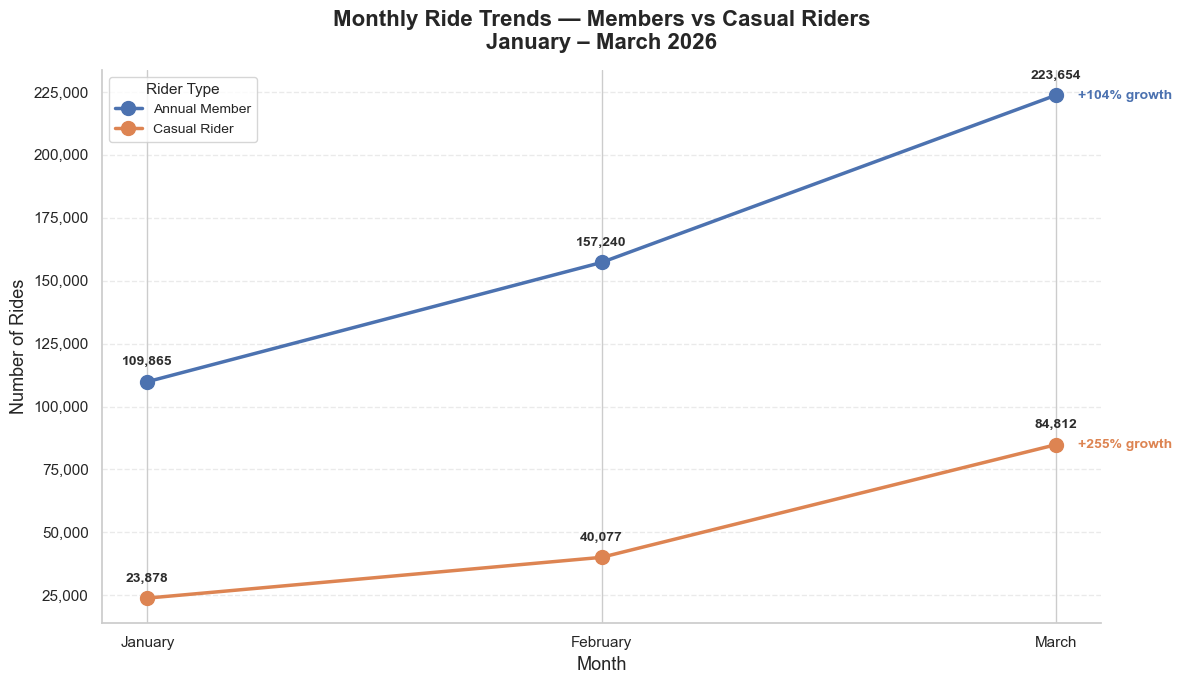

 Chart 4 saved successfully!


In [ ]:
# ============================================================
# CHART 4 — MONTHLY RIDE TRENDS 
# ============================================================

# Step 1 — Create figure
fig, ax = plt.subplots(figsize=(12, 7))

# Step 2 — Prepare data
month_data = clean_df.groupby(
    ['month', 'member_casual']
).size().reset_index(name='rides')

month_order = ['January', 'February', 'March']
month_data['month'] = pd.Categorical(
    month_data['month'],
    categories=month_order,
    ordered=True
)
month_data = month_data.sort_values('month')

# Step 3 — Separate member and casual data
member_data = month_data[month_data['member_casual'] == 'member'].sort_values('month')
casual_data = month_data[month_data['member_casual'] == 'casual'].sort_values('month')

# Step 4 — Draw lines manually using ax.plot()
# This gives us full control over legend handles
# marker='o' adds circle dots at each data point
# markersize=10 makes dots clearly visible
# linewidth=2.5 makes line thick and clear
# label= ensures legend shows correct symbol type for both lines
ax.plot(
    member_data['month'].astype(str),  # x axis — month names as strings
    member_data['rides'],               # y axis — ride counts
    color='#4C72B0',                   # original blue
    marker='o',
    markersize=10,
    linewidth=2.5,
    label='Annual Member'              # legend label
)

ax.plot(
    casual_data['month'].astype(str),
    casual_data['rides'],
    color='#DD8452',                   # original orange
    marker='o',
    markersize=10,
    linewidth=2.5,
    label='Casual Rider'               # legend label
)

# Step 5 — Add value labels at each data point
for _, row in member_data.iterrows():
    ax.annotate(
        f"{row['rides']:,}",
        xy=(str(row['month']), row['rides']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#2d2d2d'
    )

for _, row in casual_data.iterrows():
    ax.annotate(
        f"{row['rides']:,}",
        xy=(str(row['month']), row['rides']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#2d2d2d'
    )

# Step 6 — Growth percentage annotations
member_growth = (member_data['rides'].iloc[-1] - member_data['rides'].iloc[0]) / member_data['rides'].iloc[0] * 100
casual_growth = (casual_data['rides'].iloc[-1] - casual_data['rides'].iloc[0]) / casual_data['rides'].iloc[0] * 100

# iloc[0] = first row (January), iloc[-1] = last row (March)
# This calculates % change from January to March automatically
ax.text(2.05, member_data['rides'].iloc[-1],
        f'+{member_growth:.0f}% growth',
        fontsize=10, color='#4C72B0',
        fontweight='bold', va='center')

ax.text(2.05, casual_data['rides'].iloc[-1],
        f'+{casual_growth:.0f}% growth',
        fontsize=10, color='#DD8452',
        fontweight='bold', va='center')

# Step 7 — Titles and labels
ax.set_title('Monthly Ride Trends — Members vs Casual Riders\nJanuary – March 2026',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Number of Rides', fontsize=13)

# Step 8 — Format y axis
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Step 9 — Legend — now both show line+dot symbols correctly
# because we used ax.plot() with label= for both lines
ax.legend(
    title='Rider Type',
    title_fontsize=11,
    fontsize=10,
    framealpha=0.8
)

# Step 10 — Clean spines and grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    r"E:\Portofolio Projects\Cyclistic_Case_Study\Visualization\04_monthly_trends.png",
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(" Chart 4 saved successfully!")

### Chart 4 Finding: Casual Ridership Growing 2.5x Faster

**What it shows:** How total rides changed month over month for each rider type from January through March 2026.

**Key finding:**
- **Casual riders** grew **255%** from January (23,878) to March (84,812)
- **Annual members** grew **104%** from January (109,865) to March (223,654)
- Casual ridership is growing **2.5x faster** than member ridership as spring approaches

**Business implication:** This explosive casual growth into spring represents the **single best window for membership conversion campaigns.** Casual riders are becoming increasingly active and engaged; they are literally warming up to the service as weather improves. A spring membership promotion timed to **March through June** would catch casual riders at their highest engagement and motivation to ride more. Missing this window means waiting another full year.

---
### Chart 5: Rides by Bike Type

Understanding bike type preferences helps us understand what casual riders value most about the Cyclistic service. This grouped bar chart compares electric vs classic bike usage across both rider types. Preference for electric bikes signals a desire for comfort and ease over exertion, an important signal for how to frame membership messaging.

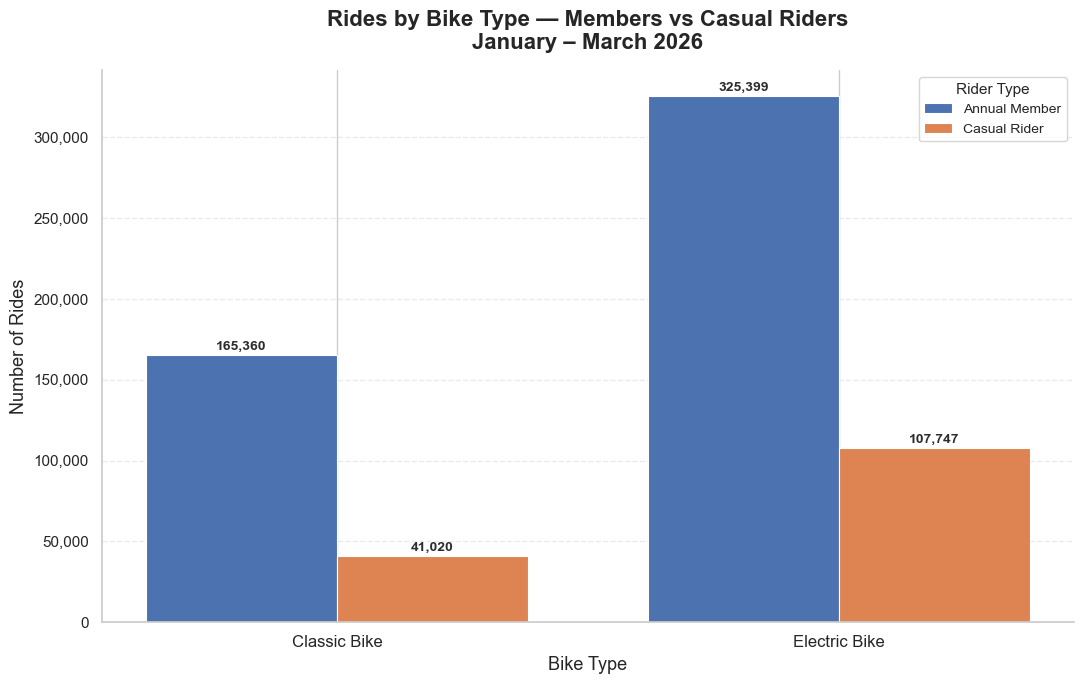

 Chart 5 saved successfully!


In [18]:
# ============================================================
# CHART 5 — RIDES BY BIKE TYPE 
# ============================================================

# Step 1 — Create figure
fig, ax = plt.subplots(figsize=(11, 7))

# Step 2 — Prepare data
bike_data = clean_df.groupby(
    ['rideable_type', 'member_casual']
).size().reset_index(name='rides')

# Step 3 — Make bike type names readable
bike_data['rideable_type'] = bike_data['rideable_type'].map({
    'electric_bike': 'Electric Bike',
    'classic_bike': 'Classic Bike'
})

# Step 4 — Separate member and casual data
# Sort by rideable_type so Classic and Electric are in same order for both
member_data = bike_data[bike_data['member_casual'] == 'member'].sort_values('rideable_type')
casual_data = bike_data[bike_data['member_casual'] == 'casual'].sort_values('rideable_type')

# Step 5 — Set bar positions manually
# 2 bike types so x = [0, 1]
x = np.arange(len(member_data))
bar_width = 0.38

# Step 6 — Draw bars manually with label=
# This is the fix — ax.bar() with label= always shows
# correct rectangle symbols in legend unlike sns.barplot()
member_bars = ax.bar(
    x - bar_width / 2,
    member_data['rides'].values,
    width=bar_width,
    color='#4C72B0',        # original blue
    edgecolor='white',
    linewidth=0.8,
    label='Annual Member'   # correct legend label
)

casual_bars = ax.bar(
    x + bar_width / 2,
    casual_data['rides'].values,
    width=bar_width,
    color='#DD8452',        # original orange
    edgecolor='white',
    linewidth=0.8,
    label='Casual Rider'    # correct legend label
)

# Step 7 — Add value labels on top of each bar
for bar in member_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1500,
        f'{height:,.0f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#2d2d2d'
    )

for bar in casual_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1500,
        f'{height:,.0f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color='#2d2d2d'
    )

# Step 8 — Set x axis ticks and labels
# We tell matplotlib exactly where ticks go (x positions)
# and what to label them (bike type names)
ax.set_xticks(x)
ax.set_xticklabels(
    member_data['rideable_type'].values,
    fontsize=12
)

# Step 9 — Titles and labels
ax.set_title('Rides by Bike Type — Members vs Casual Riders\nJanuary – March 2026',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Bike Type', fontsize=13)
ax.set_ylabel('Number of Rides', fontsize=13)

# Step 10 — Format y axis
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Step 11 — Legend — correct colored rectangles
ax.legend(
    title='Rider Type',
    title_fontsize=11,
    fontsize=10,
    framealpha=0.8
)

# Step 12 — Clean spines and grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    r"E:\Portofolio Projects\Cyclistic_Case_Study\Visualization\05_rides_by_bike_type.png",
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(" Chart 5 saved successfully!")

### Chart 5 Finding: Both Groups Prefer Electric, Casuals Even More So

**What it shows:** A comparison of electric vs classic bike usage broken down by rider type.

**Key finding:**
- **Casual riders** use electric bikes for **72.4%** of their rides (107,747 out of 148,767)
- **Annual members** use electric bikes for **66.3%** of their rides (325,399 out of 490,759)
- Both groups strongly prefer electric bikes, but casual riders even more so
- Classic bikes account for only **27.6%** of casual rides

**Business implication:** Casual riders are comfort and convenience driven. They choose the easier, more effortless option even at potentially higher per-ride cost. This is a powerful insight for membership marketing, a premium membership tier that includes **guaranteed electric bike availability** or **reduced e-bike unlock fees** would directly appeal to what casual riders already value most about the service.

---
### Chart 6: Rides by Hour of Day

Our final and most revealing visualization shows the full 24-hour riding pattern for each rider type. This chart is uniquely powerful because the *shape* of each line tells a complete story about rider behavior, without needing to read a single number. A line chart is ideal here because time of day is continuous and the trend between hours matters as much as the individual values.

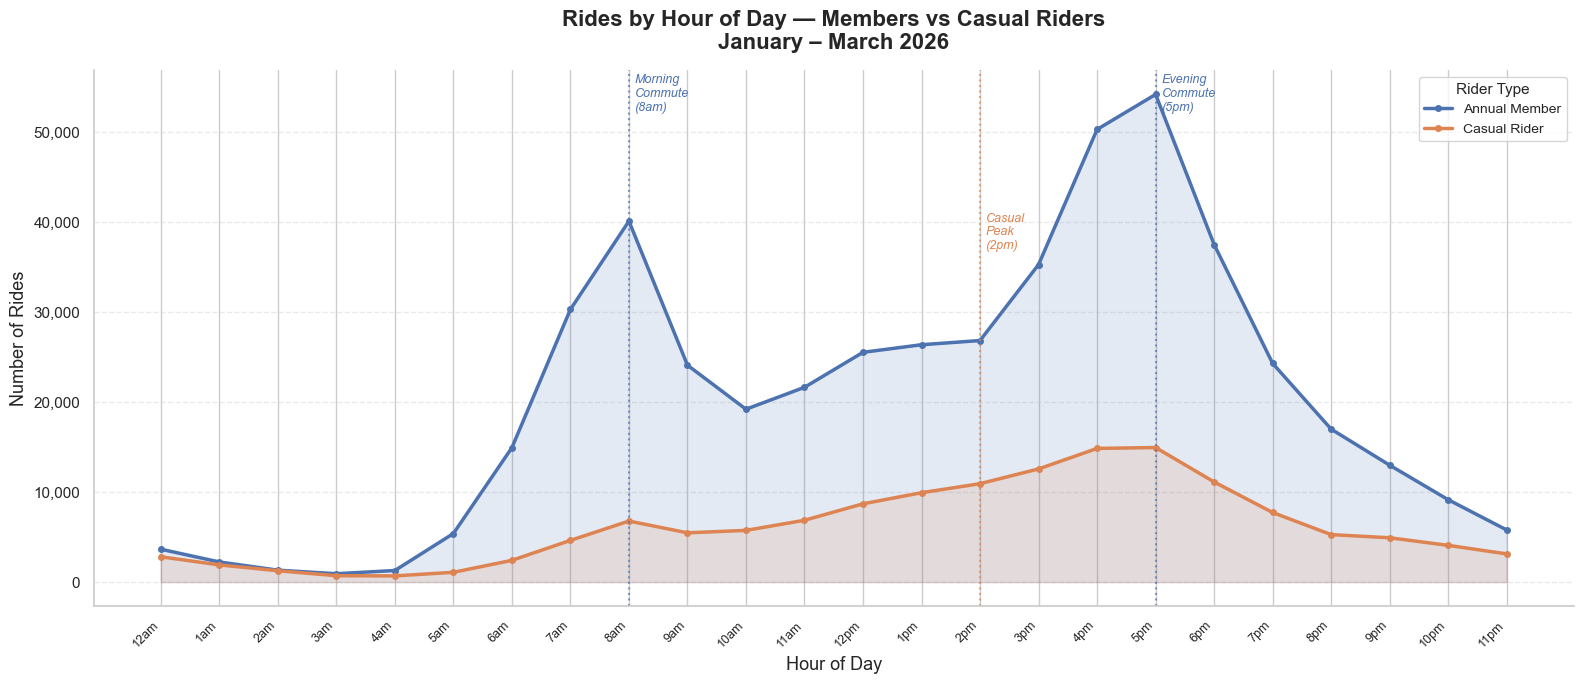

 Chart 6 saved successfully!


In [20]:
# ============================================================
# CHART 6 — PEAK HOURS BY RIDER TYPE 
# ============================================================

# Step 1 — Create figure
fig, ax = plt.subplots(figsize=(16, 7))

# Step 2 — Prepare data
hour_data = clean_df.groupby(
    ['hour', 'member_casual']
).size().reset_index(name='rides')

# Step 3 — Separate member and casual data
member_data = hour_data[hour_data['member_casual'] == 'member'].sort_values('hour')
casual_data = hour_data[hour_data['member_casual'] == 'casual'].sort_values('hour')

# Step 4 — Draw lines manually using ax.plot()
# label= ensures both legend handles show correct line symbols
member_line, = ax.plot(
    member_data['hour'],
    member_data['rides'],
    color='#4C72B0',
    linewidth=2.5,
    marker='o',
    markersize=4,
    label='Annual Member'
)

casual_line, = ax.plot(
    casual_data['hour'],
    casual_data['rides'],
    color='#DD8452',
    linewidth=2.5,
    marker='o',
    markersize=4,
    label='Casual Rider'
)

# Step 5 — Fill area under each line
# fill_between() needs the x values and y values
# alpha=0.15 keeps fill very subtle so lines stay clear
ax.fill_between(
    member_data['hour'],
    member_data['rides'],
    alpha=0.15,
    color='#4C72B0'
)

ax.fill_between(
    casual_data['hour'],
    casual_data['rides'],
    alpha=0.15,
    color='#DD8452'
)

# Step 6 — Reference lines for key times
ax.axvline(x=8, color='#4C72B0', linestyle=':', alpha=0.7, linewidth=1.5)
ax.text(8.1, ax.get_ylim()[1] * 0.92,
        'Morning\nCommute\n(8am)',
        fontsize=9, color='#4C72B0', style='italic')

ax.axvline(x=17, color='#4C72B0', linestyle=':', alpha=0.7, linewidth=1.5)
ax.text(17.1, ax.get_ylim()[1] * 0.92,
        'Evening\nCommute\n(5pm)',
        fontsize=9, color='#4C72B0', style='italic')

ax.axvline(x=14, color='#DD8452', linestyle=':', alpha=0.7, linewidth=1.5)
ax.text(14.1, ax.get_ylim()[1] * 0.65,
        'Casual\nPeak\n(2pm)',
        fontsize=9, color='#DD8452', style='italic')

# Step 7 — X axis hour labels
ax.set_xticks(range(0, 24))
hour_labels = [
    '12am' if h == 0
    else '12pm' if h == 12
    else f'{h}am' if h < 12
    else f'{h-12}pm'
    for h in range(0, 24)
]
ax.set_xticklabels(hour_labels, fontsize=9, rotation=45, ha='right')

# Step 8 — Titles and labels
ax.set_title('Rides by Hour of Day — Members vs Casual Riders\nJanuary – March 2026',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day', fontsize=13)
ax.set_ylabel('Number of Rides', fontsize=13)

# Step 9 — Format y axis
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

# Step 10 — Legend
# Because we used ax.plot() with label= for both lines
# legend now correctly shows line symbols for both 
ax.legend(
    title='Rider Type',
    title_fontsize=11,
    fontsize=10,
    framealpha=0.8
)

# Step 11 — Clean spines and grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, alpha=0.4, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    r"E:\Portofolio Projects\Cyclistic_Case_Study\Visualization\06_peak_hours.png",
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print(" Chart 6 saved successfully!")

### Chart 6 Finding: The Commuter vs Leisure Signature

**What it shows:** Total rides for every hour of the day (midnight to 11pm) for both rider types, with reference lines marking key peak moments.

**Key finding:** The shape of each line tells the complete behavioral story:
- **Members** show a clear **double-peak pattern**, with a sharp spike at **8am** (40,139 rides) representing the morning commute, dropping during midday, then spiking again even higher at **5pm** (54,226 rides) for the evening commute. This is the textbook signature of a commuter.
- **Casual riders** show a completely different **single smooth curve**, gradually rising from morning, peaking around **2pm–5pm** and declining through the evening. No morning rush whatsoever. This is the textbook signature of a leisure rider.
- Between **midnight and 5am** both groups drop to minimal activity, as expected
- After **7pm** casual riders maintain a relatively higher proportion of rides than during mornings

**Business implication:** This chart alone could justify the entire marketing strategy. It confirms beyond doubt that members and casual riders are using the same bikes for completely different purposes. It also reveals a **practical targeting insight**: digital ads and in-app promotions served to casual riders between **11am and 4pm** on weekends will reach them at exactly the moment they are most actively riding. Morning push notifications would be completely wasted on this audience.

---

### All 6 Visualizations Complete

All charts have been saved to the `Visualizations/` folder and are ready for import into Tableau and the final PDF report. Together these 6 charts tell a complete and compelling story:

1. Members dominate volume but casuals are a massive opportunity
2. Casuals ride longer; they value the experience not just the destination
3. Casuals peak on weekends, members peak midweek (opposite behaviors)
4. Casual growth is explosive into spring; the conversion window is now
5. Both groups love electric bikes, casuals even more so
6. The double commute peak vs leisure curve confirms two completely different rider personas

These findings directly power our **3 strategic recommendations** in the final section.

---
## Phase 8: Export Clean Master Dataset

We export our final cleaned and enriched dataset as a CSV file. This file will serve as the primary data source for our **Tableau dashboard** in the next phase of the project.

The exported file contains all 639,546 clean rides with the original 13 columns plus our 5 newly engineered columns: `ride_length_mins`, `day_of_week`, `month`, `hour` and `date`.

In [21]:
# ============================================================
# CELL 9 — EXPORT CLEAN MASTER CSV FOR TABLEAU
# ============================================================

# Define export path
export_path = r"E:\Portofolio Projects\Cyclistic_Case_Study\Data\Processed\cyclistic_clean_master.csv"

# to_csv() converts our dataframe into a CSV file
# index=False means don't write the row numbers (0,1,2,3...)
# as a column — we don't need them in our export
clean_df.to_csv(export_path, index=False)

print("=" * 55)
print(" EXPORT SUMMARY")
print("=" * 55)
print(f"\n File saved to:")
print(f"   {export_path}")
print(f"\n Dataset details:")
print(f"   Total rows    : {len(clean_df):,}")
print(f"   Total columns : {len(clean_df.columns)}")
print(f"\n Columns exported:")
for i, col in enumerate(clean_df.columns, 1):
    print(f"   {i:02d}. {col}")

# Close the SQLite database connection
conn.close()
print(f"\n SQLite database connection closed")
print(f" Ready for Tableau!")

 EXPORT SUMMARY

 File saved to:
   E:\Portofolio Projects\Cyclistic_Case_Study\Data\Processed\cyclistic_clean_master.csv

 Dataset details:
   Total rows    : 639,526
   Total columns : 18

 Columns exported:
   01. ride_id
   02. rideable_type
   03. started_at
   04. ended_at
   05. start_station_name
   06. start_station_id
   07. end_station_name
   08. end_station_id
   09. start_lat
   10. start_lng
   11. end_lat
   12. end_lng
   13. member_casual
   14. ride_length_mins
   15. day_of_week
   16. month
   17. hour
   18. date

 SQLite database connection closed
 Ready for Tableau!


### Export Complete

The clean master dataset has been saved to `Data/Processed/cyclistic_clean_master.csv` and is ready to be connected to Tableau for dashboard creation.

**File contains:**
- 639,526 rows of clean validated ride data
- 18 columns including all original and engineered features
- Zero duplicates and zero impossible ride lengths
- Consistent standardized text values throughout

The SQLite database connection has been properly closed. 

---
## Phase 9: Conclusions & Top 3 Recommendations

Having completed our full analysis across Excel, SQL and Python, I now synthesize everything into clear actionable recommendations for the Cyclistic marketing team. Every recommendation below is directly supported by data findings from this notebook.

In [22]:
# ============================================================
# CELL 10 — FINAL SUMMARY & RECOMMENDATIONS
# ============================================================

print("=" * 55)
print(" CYCLISTIC ANALYSIS — FINAL SUMMARY")
print("=" * 55)

# Calculate all key metrics for summary
total        = len(clean_df)
members      = len(clean_df[clean_df['member_casual'] == 'member'])
casuals      = len(clean_df[clean_df['member_casual'] == 'casual'])
avg_member   = clean_df[clean_df['member_casual'] == 'member']['ride_length_mins'].mean()
avg_casual   = clean_df[clean_df['member_casual'] == 'casual']['ride_length_mins'].mean()
diff         = ((avg_casual - avg_member) / avg_member) * 100
casual_elec  = len(clean_df[(clean_df['member_casual'] == 'casual') &
                             (clean_df['rideable_type'] == 'electric_bike')])
member_elec  = len(clean_df[(clean_df['member_casual'] == 'member') &
                             (clean_df['rideable_type'] == 'electric_bike')])

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Period              : January – March 2026
 Total clean rides   : {total:,}
 Annual members      : {members:,} ({members/total*100:.1f}%)
 Casual riders       : {casuals:,} ({casuals/total*100:.1f}%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY BEHAVIORAL DIFFERENCES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Avg member ride     : {avg_member:.1f} minutes
 Avg casual ride     : {avg_casual:.1f} minutes
 Difference          : Casual rides {diff:.1f}% longer

 Member peak day     : Tuesday  (commuter pattern)
 Casual peak day     : Saturday (leisure pattern)

 Member peak hours   : 8am & 5pm (double commute peak)
 Casual peak hours   : 2pm – 5pm (single leisure curve)

 Casual electric %   : {casual_elec/casuals*100:.1f}%
 Member electric %   : {member_elec/members*100:.1f}%

 Casual growth       : +255% from January to March
 Member growth       : +104% from January to March

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TOP 3 RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 1. SPRING WEEKEND MEMBERSHIP DRIVE
    Casual ridership grew 255% from Jan to Mar and peaks on Saturdays. Launch a targeted spring membership campaign (March–June) at high casual
    stations like Navy Pier with a limited time discounted annual membership offer for riders who have taken 3+ rides in the past 30 days.

 2. MARKET VALUE AROUND RIDE DURATION
    Casual riders average {avg_casual:.1f} mins per ride — {diff:.1f}% longer than members. A digital campaign showing cost per minute savings with 
    an annual membership would speak directly to how casual riders already use the service.
    Message: "You rode {avg_casual:.0f} mins — a membership saves you 60% per ride at your riding frequency."

 3. PREMIUM ELECTRIC BIKE MEMBERSHIP TIER
    {casual_elec/casuals*100:.1f}% of casual rides use electric bikes — higher than members at {member_elec/members*100:.1f}%. 
    A premium membership tier offering guaranteed e-bike availability or reduced unlock fees would directly target what casual riders value most.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 LIMITATIONS & NEXT STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 - Analysis covers winter/early spring only — summer peak season patterns not captured.
 - Cannot track individual casual riders across multiple rides due to privacy restrictions.
 - Cannot determine tourist vs resident casual riders — affects marketing channel selection.

 Next steps:
 - Expand to full 12 months for seasonal analysis.
 - Survey casual riders on membership barriers.
 - A/B test spring campaign at Navy Pier vs control stations to measure conversion rate.
 - Target casual riders with 5+ rides per month as highest priority conversion candidates.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print(" Analysis complete!")
print(" Next step: Tableau Dashboard")

 CYCLISTIC ANALYSIS — FINAL SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Period              : January – March 2026
 Total clean rides   : 639,526
 Annual members      : 490,759 (76.7%)
 Casual riders       : 148,767 (23.3%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY BEHAVIORAL DIFFERENCES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Avg member ride     : 11.2 minutes
 Avg casual ride     : 15.6 minutes
 Difference          : Casual rides 38.7% longer

 Member peak day     : Tuesday  (commuter pattern)
 Casual peak day     : Saturday (leisure pattern)

 Member peak hours   : 8am & 5pm (double commute peak)
 Casual peak hours   : 2pm – 5pm (single leisure curve)

 Casual electric %   : 72.4%
 Member electric %   : 66.3%

 Casual growth       : +255% from January to March
 Member growth       : +104% from January to March

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━